# Customer Churn Analysis & Retentition

# *****

# Problem Statement: Customers leave companies due to various reasons and the main goal of this project is to analysis the data and identify the key factors contributing to the Churn .

# Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load dataset

In [28]:
df=pd.read_csv(r"C:\Users\akars\Downloads\archive (1)\telco.csv")

In [29]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


# Basic Information 

In [30]:
df.size

352150

In [31]:
df.index

RangeIndex(start=0, stop=7043, step=1)

In [32]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [33]:
df.describe() #Statistical data calculation

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [35]:
df.values #return numpy data as ndarray

array([['8779-QRDMV', 'Male', 78, ..., 5433, 'Competitor',
        'Competitor offered more data'],
       ['7495-OOKFY', 'Female', 74, ..., 5302, 'Competitor',
        'Competitor made better offer'],
       ['1658-BYGOY', 'Male', 71, ..., 3179, 'Competitor',
        'Competitor made better offer'],
       ...,
       ['2234-XADUH', 'Female', 30, ..., 5560, nan, nan],
       ['4801-JZAZL', 'Female', 32, ..., 2793, nan, nan],
       ['3186-AJIEK', 'Male', 44, ..., 5097, nan, nan]],
      shape=(7043, 50), dtype=object)

# Data Cleaning

# Check for Missing values in data sets and drop any duplicates if present in it.

In [36]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

# Convert Total Charges to Numeric

In [37]:
df["Total Charges"]=pd.to_numeric(df["Total Charges"],errors="coerce") #it converts the total charges to numeric values(int,floats) and errors are to replace NaN values which are not a numbers and are not needed 

# Fill Missing Values

In [38]:
df["Total Charges"].fillna(df["Total Charges"].median(),inplace=True) #Replace all values in Total Charges Col. with the median  of the Col.&update directly.

# Convert Churn Label to Numeric

In [39]:
df["Churn Label"]=np.where(df["Churn Label"]=="Yes",1,0) #if yes then 1 if no then 0 

# Data Analysis

# Customers Churned

In [40]:
a=df["Customer Status"]=="Churned"


In [41]:
p=df[a]

In [42]:
df[[ "Customer ID","Age","State","Total Revenue","Customer Status","Churn Label"]]

,Customer ID,Age,State,Total Revenue,Customer Status,Churn Label
0,8779-QRDMV,78,California,59.65,Churned,1
1,7495-OOKFY,74,California,1024.10,Churned,1
2,1658-BYGOY,71,California,1910.88,Churned,1
3,4598-XLKNJ,78,California,2995.07,Churned,1
4,4846-WHAFZ,80,California,3102.36,Churned,1
...,...,...,...,...,...,...
7038,2569-WGERO,30,California,3039.53,Stayed,0
7039,6840-RESVB,38,California,2807.47,Stayed,0
7040,2234-XADUH,30,California,9453.04,Stayed,0
7041,4801-JZAZL,32,California,319.21,Stayed,0


# Overall Churn Rate 

In [43]:
# Churn Rate
churn_rate = df['Churn Label'].mean()*100
print("Churn Rate:", churn_rate)

Churn Rate: 26.536987079369588


# From above we analyised that about 26.53698 % customers have Churned .

# Identify Segment where Churn rates more than average

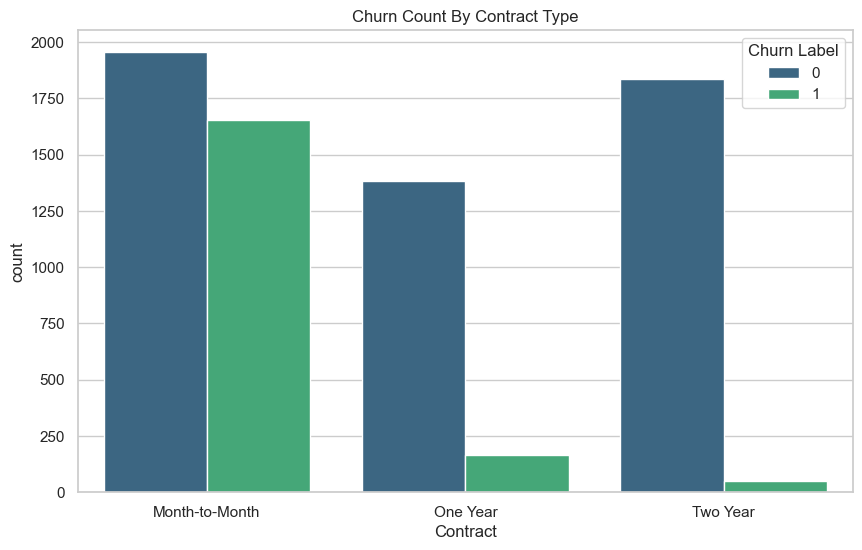

Churn Rate by Contract:
 Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn Label, dtype: float64


In [44]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Contract", hue="Churn Label", palette="viridis")#countplot counts customer in each category
plt.title("Churn Count By Contract Type")
plt.show()
contract_churn = df.groupby('Contract')['Churn Label'].mean() * 100 #group customers in specific contract group.
print("Churn Rate by Contract:\n", contract_churn)

# The Month-to-Month Risk: vast majority of churned customers are on Month-to-Month Contracts .These customers have no long-term commitment so more likely to switch to a competitor. In one year Contract seems less or little risk but in two year contract we see Retention in Long Term Contracts as almost zero Churn ,customers stayed here most .

# Bussiness Recommendation: To reduce the overall churn rate from 26.5%, the company should offers discounts,loyality bonuses to customers to transition them from Month-to-Month contract to one Year Plan or even provide better opportunities so stayed till two year.

# Identify Pain Points(Reasons of Churn)

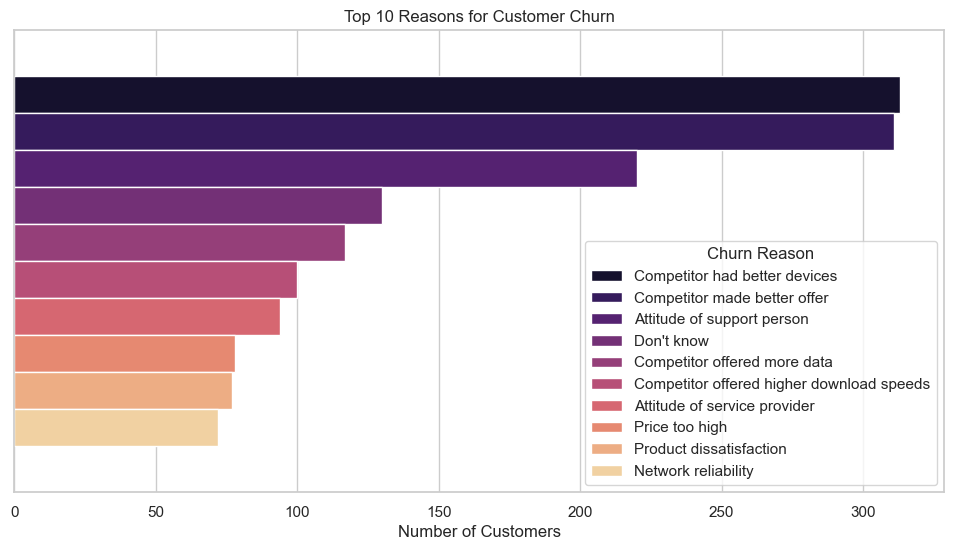

In [45]:
# Top 10 Reasons for Churning
plt.figure(figsize=(12, 6))
churn_reasons = df[df['Churn Label'] == 1]['Churn Reason'].value_counts().head(10)
sns.barplot(x=churn_reasons.values,  hue=churn_reasons.index, palette='magma')
plt.title('Top 10 Reasons for Customer Churn')
plt.xlabel('Number of Customers')
plt.show()

# The top reasons -Competitor had better devices and Competitor made better offer this shows market is highly aggresive . we are losing our customers to rivals who have better hardware devices or pricing. Reasons like Attitude of support person in top 5 suggest an internal operational issue which can be resolved using better staff.

# Tenure VS Churn Score

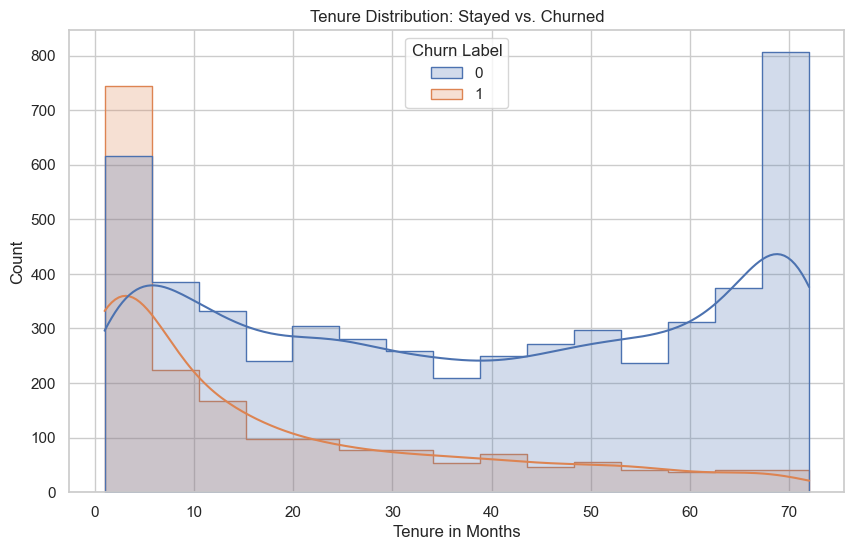

In [46]:
# Relationship between Tenure and Churn Score
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Tenure in Months', hue='Churn Label', kde=True, element="step")
plt.title('Tenure Distribution: Stayed vs. Churned')
plt.show()

# there is massive orange spike between 0-6 months indicate "welcome period" failure most customers are leaving immediately,U shaped distributed(blue) notices customer stayed if for One year they are loyal ,High Churn Score:low Tenure=High Churn Risk.

# Business recommendation: Company shouldn't initially focus on marketing rather focus on customer stay in first 3 months with calls or assistance to get the danger zone passed.

# Financial Impact

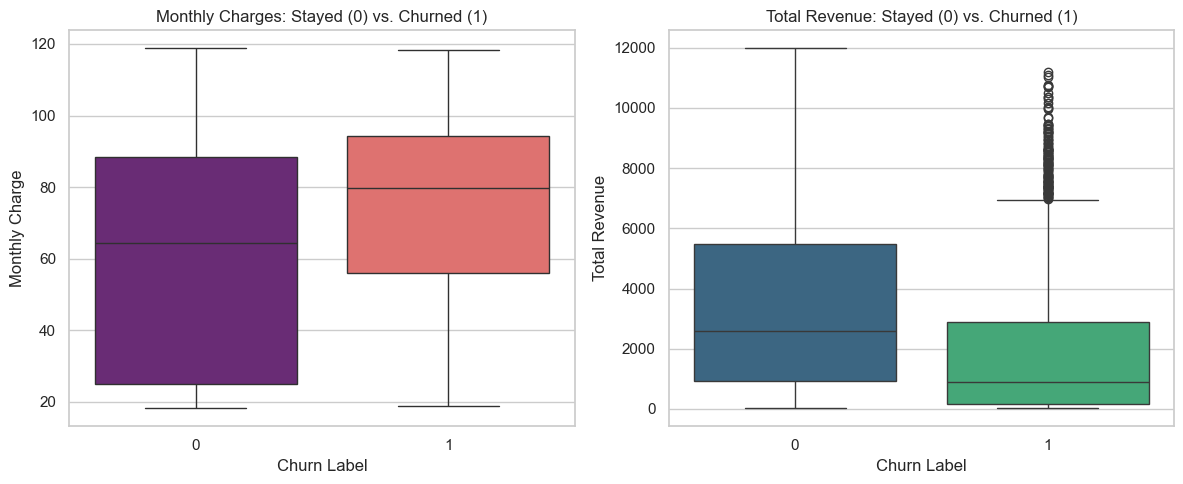

            Monthly Charge                                      ...  \
                     count       mean        std    min    25%  ...   
Churn Label                                                     ...   
0                   5174.0  61.265124  31.092648  18.25  25.10  ...   
1                   1869.0  74.441332  24.666053  18.85  56.15  ...   

            Total Revenue                                         
                      min      25%       50%       75%       max  
Churn Label                                                       
0                   21.36  938.575  2579.325  5463.415  11979.34  
1                   21.61  175.850   893.550  2888.760  11195.44  

[2 rows x 16 columns]


In [51]:
# Comparison of Monthly Charges and Total Revenue
plt.figure(figsize=(12, 5))

# Plot 1: Monthly Charges
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Churn Label', y='Monthly Charge', hue='Churn Label', palette='magma', legend=False)
plt.title('Monthly Charges: Stayed (0) vs. Churned (1)')

# Plot 2: Total Revenue
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn Label', y='Total Revenue', hue='Churn Label', palette='viridis', legend=False)
plt.title('Total Revenue: Stayed (0) vs. Churned (1)')

plt.tight_layout()
plt.show()

# Quick summary statistics
print(df.groupby('Churn Label')[['Monthly Charge', 'Total Revenue']].describe())

# Monthly Charges: The box for Churned customers (1) sits significantly higher than the box for Stayed customers (0). This confirms that high monthly bills are a primary driver for people leaving.

# Total Revenue: The "Stayed" group has a much "taller" box with many outliers. This is because long-term customers contribute much more to the company's bottom line over time, whereas churned customers leave before they become profitable.